<a href="https://colab.research.google.com/github/Akshatha7710/smart-tea-estate-management-system/blob/fertilizer-scheduling-and-optimisation-model/FerilizerSchedule.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [45]:
from google.colab import drive
drive.mount ('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt
from scipy.stats import linregress

Cleaning Data, Preprocessing data and feature engineering for Fertilizer dataset.

In [47]:
#fertilizer dataset
fert = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Fertilizer_History.csv', header=None)
fert.columns = ["Division", "Field", "Area", "Type", "Date", "Amount", "Block", "Extra"]
fert = fert.drop(columns=["Extra"]).dropna(how='all')

# Keep valid rows
fert = fert[
    fert['Division'].notna() & (fert['Division'] != 0) &
    fert['Field'].notna() & (fert['Field'] != 0) & (fert['Field'] != '-')
]
fert['Division'] = fert['Division'].ffill()
fert['Area'] = pd.to_numeric(fert['Area'], errors='coerce')
fert['Amount'] = pd.to_numeric(fert['Amount'], errors='coerce')
fert = fert.dropna(subset=['Area','Amount'])

# Date preprocessing
fert['Date'] = pd.to_datetime(fert['Date'], format='%d-%b-%y', errors='coerce')
fert = fert.dropna(subset=['Date'])
fert['Month'] = fert['Date'].dt.strftime('%B')  # Month name for merge

# Feature engineering
fert['Fertilizer_per_area'] = fert['Amount'] / fert['Area']
fert = fert.sort_values(by=['Division','Field','Date']).reset_index(drop=True)
fert['Prev_Amount'] = fert.groupby(['Division','Field'])['Amount'].shift(1).fillna(0)
fert['Days_since_last'] = fert.groupby(['Division','Field'])['Date'].diff().dt.days.fillna(0)
fert_monthly = fert.groupby(['Division','Field','Month']).agg({
    'Amount':'sum',
    'Fertilizer_per_area':'mean',
    'Prev_Amount':'sum',
    'Days_since_last':'mean'
}).reset_index()
fert_monthly['Applied'] = (fert_monthly['Amount']>0).astype(int)

Cleaning Data, Preprocessing data and feature engineering for the yeild dataset.

In [48]:
#yeild dataset
yield_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Block_Metadata.csv', header=None)
yield_df = yield_df.dropna(how='all').reset_index(drop=True)
yield_df = yield_df.iloc[4:].reset_index(drop=True)

yield_df.columns = [
    'Division', 'Asst_Manager', 'Field', 'Area', 'Type',
    'Planting_Year', 'Last_Pruned', 'Age_Months'
] + [f'Year_{i}' for i in range(1, yield_df.shape[1]-8+1)]

# Cleaning numeric columns
numeric_cols = ['Area','Age_Months'] + [f'Year_{i}' for i in range(1, yield_df.shape[1]-8+1)]
for col in numeric_cols:
    yield_df[col] = pd.to_numeric(yield_df[col].astype(str).str.replace(',',''), errors='coerce')
yield_df[numeric_cols] = yield_df[numeric_cols].fillna(yield_df[numeric_cols].median())
yield_df['Division'] = yield_df['Division'].ffill()
yield_df['Field'] = yield_df['Field'].ffill()
yield_df['Last_Pruned'] = pd.to_datetime(yield_df['Last_Pruned'], errors='coerce', dayfirst=True)

# Feature engineering
yield_df['Yield_per_ha'] = yield_df['Year_1'] / yield_df['Area']
last_5_cols = [col for col in yield_df.columns if 'Year_' in col][:5]
yield_df['Avg_Yield_Last5Y'] = yield_df[last_5_cols].mean(axis=1)
yield_df['Yield_Trend'] = yield_df['Year_1'] - yield_df['Avg_Yield_Last5Y']
yield_df['Months_Since_Pruning'] = yield_df['Age_Months'] - ((pd.to_datetime('2025-09-01') - yield_df['Last_Pruned']).dt.days/30)
yield_df['Months_Since_Pruning'] = yield_df['Months_Since_Pruning'].fillna(yield_df['Months_Since_Pruning'].median())

yield_features = yield_df[['Division','Field','Area','Age_Months','Yield_per_ha','Avg_Yield_Last5Y','Yield_Trend','Months_Since_Pruning']]

# Expand yield per block to all 12 months for merging
months_list = ['January','February','March','April','May','June','July','August','September','October','November','December']
yield_monthly = yield_features.loc[yield_features.index.repeat(12)].reset_index(drop=True)
yield_monthly['Month'] = months_list * len(yield_features)


/tmp/ipython-input-4061435099.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  yield_df['Last_Pruned'] = pd.to_datetime(yield_df['Last_Pruned'], errors='coerce', dayfirst=True)


Cleaning Data, Preprocessing data and feature engineering for climate dataset.

In [49]:
#Climate dataset
climate = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/DSGP/Climate_Data.csv', header=None)
climate = climate.dropna(how='all').reset_index(drop=True)

months = ['January','February','March','April','May','June','July','August','September','October','November','December']
climate = climate[climate[0].str.strip().isin(months)].reset_index(drop=True)

n_cols = climate.shape[1]
columns = ['Month']
num_years = (n_cols - 1)//2
for i in range(num_years):
    columns += [f'Wetdays_Year_{i+1}', f'Rainfall_Year_{i+1}']
if len(columns) != n_cols:
    columns += [f'Extra_{i}' for i in range(len(columns), n_cols)]
climate.columns = columns

# Clean numeric
for col in climate.columns[1:]:
    climate[col] = pd.to_numeric(climate[col].astype(str).str.replace(',','').str.replace('-','').str.strip(), errors='coerce')
non_empty_cols = [c for c in climate.columns if climate[c].notna().sum() > 0 or c=='Month']
climate = climate[non_empty_cols]

rainfall_cols = [c for c in climate.columns if 'Rainfall' in c]
wetdays_cols = [c for c in climate.columns if 'Wetdays' in c]

climate['Rainfall_Mean'] = climate[rainfall_cols].mean(axis=1)
climate['Rainfall_Max'] = climate[rainfall_cols].max(axis=1)
climate['Rainfall_Min'] = climate[rainfall_cols].min(axis=1)
climate['Wetdays_Mean'] = climate[wetdays_cols].mean(axis=1)

def compute_trend(row):
    y = row[rainfall_cols].values.astype(float)
    valid_idx = ~np.isnan(y)
    if valid_idx.sum()<2:
        return 0
    x = np.arange(len(y))
    slope, _, _, _, _ = linregress(x[valid_idx], y[valid_idx])
    return slope

climate['Rainfall_Trend'] = climate.apply(compute_trend, axis=1)

Merging the datasets


In [50]:
merged_df = pd.merge(yield_monthly, fert_monthly, on=['Division','Field','Month'], how='left')
merged_df = pd.merge(merged_df, climate, on='Month', how='left')

num_cols = merged_df.select_dtypes(include=np.number).columns
merged_df[num_cols] = merged_df[num_cols].fillna(0)

print("\nFinal Merged DSGP Dataset:")
print(merged_df.head())
print("\nShape:", merged_df.shape)
print("\nMissing values summary:")
print(merged_df.isna().sum())


Final Merged DSGP Dataset:
  Division Field  Area  Age_Months  Yield_per_ha  Avg_Yield_Last5Y  \
0      LVO     1   4.0        24.0        235.75            1228.8   
1      LVO     1   4.0        24.0        235.75            1228.8   
2      LVO     1   4.0        24.0        235.75            1228.8   
3      LVO     1   4.0        24.0        235.75            1228.8   
4      LVO     1   4.0        24.0        235.75            1228.8   

   Yield_Trend  Months_Since_Pruning     Month  Amount  ...  Rainfall_Year_9  \
0       -285.8              0.433333   January     0.0  ...             46.0   
1       -285.8              0.433333  February     0.0  ...             95.0   
2       -285.8              0.433333     March     0.0  ...            164.0   
3       -285.8              0.433333     April     0.0  ...              0.0   
4       -285.8              0.433333       May     0.0  ...            856.0   

   Wetdays_Year_10  Rainfall_Year_10  Wetdays_Year_11  Rainfall_Year_1

Performing Exploratory data analysis on the merged dataset

/tmp/ipython-input-2405537956.py:5: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df, x='Month', y='Yield_per_ha', hue='Division', ci=None)


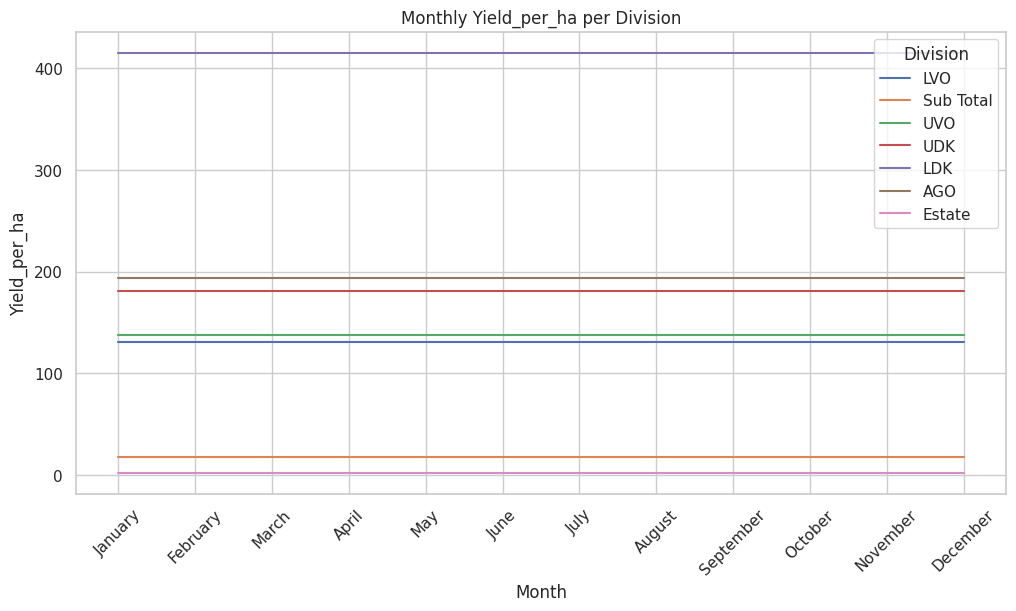

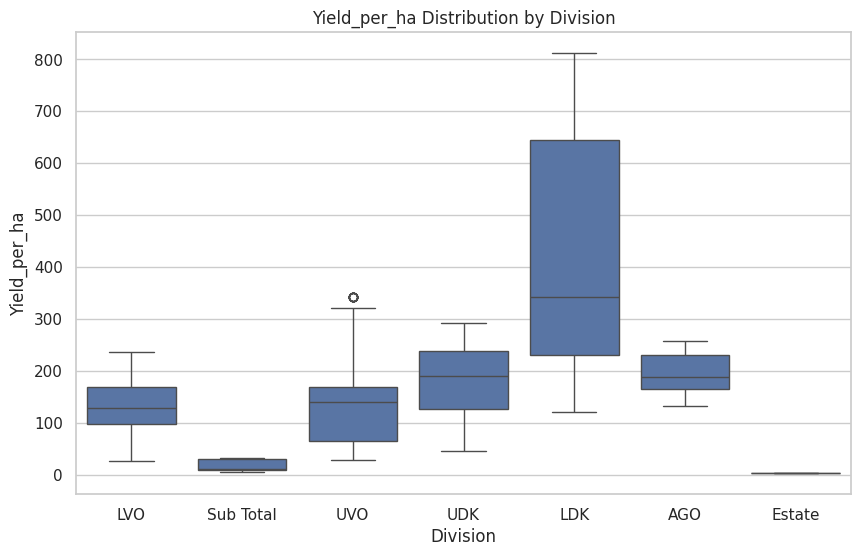

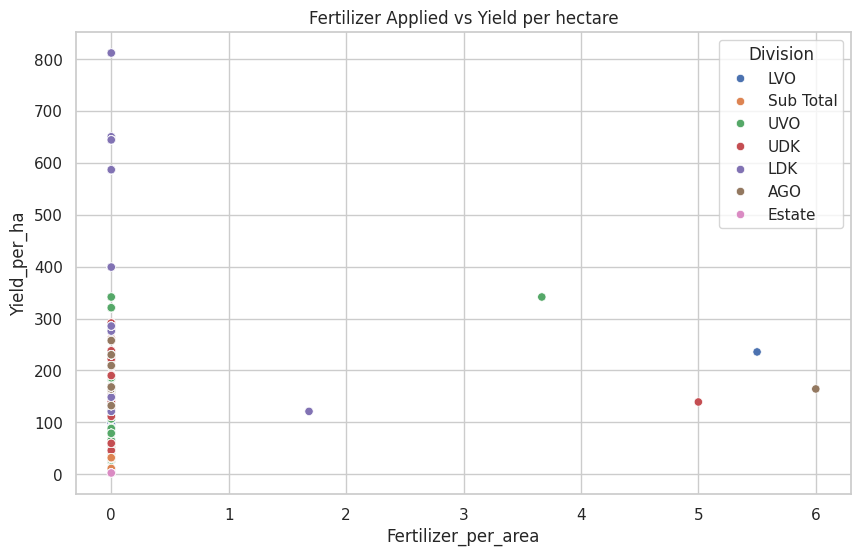


Top correlated numeric features with Yield_per_ha:
 Avg_Yield_Last5Y        6.375648e-01
Area                    2.617416e-01
Yield_Trend             1.647421e-01
Months_Since_Pruning    1.036778e-01
Age_Months              9.630821e-02
Fertilizer_per_area     1.324839e-02
Applied                 1.274726e-02
Amount                  2.849103e-03
Wetdays_Year_9          9.095227e-16
Name: Yield_per_ha, dtype: float64


In [52]:
df = merged_df.copy()

#Lineplot: Yield_per_ha across months per Division
plt.figure(figsize=(12,6))
sns.lineplot(data=df, x='Month', y='Yield_per_ha', hue='Division', ci=None)
plt.title("Monthly Yield_per_ha per Division")
plt.xticks(rotation=45)
plt.show()

#Boxplot: Distribution of Yield_per_ha per Division
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Division', y='Yield_per_ha')
plt.title("Yield_per_ha Distribution by Division")
plt.show()

#Scatterplot: Fertilizer_per_area vs Yield_per_ha
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Fertilizer_per_area', y='Yield_per_ha', hue='Division')
plt.title("Fertilizer Applied vs Yield_per_ha")
plt.show()

#Top correlations only
numeric_cols = df.select_dtypes(include=np.number).columns
corr_matrix = df[numeric_cols].corr()
top_corr = corr_matrix['Yield_per_ha'].abs().sort_values(ascending=False)[1:10]
print("\nTop correlated numeric features with Yield_per_ha:\n", top_corr)